In [ ]:
## install finrl library if not installed

import pkg_resources
import pip
installedPackages = {pkg.key for pkg in pkg_resources.working_set} # list of installed packages

required = {'pandas','numpy', 'matplotlib','pyfolio-reloaded','yfinance','empyrical'
            }
missing = required - installedPackages
if missing:

    !pip install pandas
    !pip install numpy
    !pip install matplotlib
    !pip install pyfolio-reloaded
    !pip install yfinance
    !pip install empyrical

# Portfolio Evaluation
This notebook computes cumulative returns and performance metrics for benchmark and portfolio strategies.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir("drive/My Drive/Asset_Allocation")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


FileNotFoundError: [Errno 2] No such file or directory: 'drive/My Drive/Asset_Allocation'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import pyfolio as pf
from pyfolio import timeseries
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

In [ ]:
min_var_weights = pd.read_pickle('datasets/max_sharpe_weights.pkl')
uniform_weights = pd.read_pickle('datasets/uniform_weights_port.pkl')
method1_weights = pd.read_pickle('datasets/min_var_weights_with_predictions.pkl')
method2_weights = pd.read_pickle('datasets/test_data_m2_weights.pkl')
test_df = pd.read_pickle('datasets/test_data_m1_month.pkl')

In [ ]:
min_var_weights.Date = pd.to_datetime(min_var_weights.Date)
uniform_weights.Date = pd.to_datetime(uniform_weights.Date)
method1_weights.Date = pd.to_datetime(method1_weights.Date)
method2_weights.Date = pd.to_datetime(method2_weights.Date)

In [ ]:
min_var_weights.reset_index(drop=True, inplace=True)
uniform_weights.reset_index(drop=True, inplace=True)
method1_weights.reset_index(drop=True, inplace=True)
method2_weights.reset_index(drop=True, inplace=True)

In [ ]:
min_var_weights.shape,uniform_weights.shape,method1_weights.shape,method2_weights.shape

((34, 31), (34, 31), (34, 31), (34, 31))

In [ ]:
min_var_weights.Date.min(),uniform_weights.Date.min(),method1_weights.Date.min(),method2_weights.Date.min()

(Timestamp('2022-01-01 00:00:00'),
 Timestamp('2022-01-01 00:00:00'),
 Timestamp('2022-01-01 00:00:00'),
 Timestamp('2022-01-01 00:00:00'))

In [ ]:
min_var_weights.Date.max(),uniform_weights.Date.max(),method1_weights.Date.max(),method2_weights.Date.max()

(Timestamp('2024-10-01 00:00:00'),
 Timestamp('2024-10-01 00:00:00'),
 Timestamp('2024-10-01 00:00:00'),
 Timestamp('2024-10-01 00:00:00'))

In [ ]:
unique_trade_date = method2_weights.Date.unique()
test_df_pivot = test_df.pivot(index='Date', columns='Ticker', values='close')

def capital(weights,test_df_pivot,unique_trade_date,portfolio):
  for t,t_1 in zip(unique_trade_date[:-1],unique_trade_date[1::]):
    weight = weights.loc[t]
    #current capital
    cap = portfolio.loc[t,'account_value']
    #current cash invested for each stock
    current_cash = [element * cap for element in list(weight.values)]
    # current held shares
    current_shares = list(np.array(current_cash)
                                      / np.array(test_df_pivot.loc[t]))
    # next time period price
    next_price = np.array(test_df_pivot.loc[t_1])
    ##next_price * current share to calculate next total account value

    portfolio.loc[t_1, 'account_value'] = np.dot(current_shares, next_price)

  return portfolio

In [ ]:
#uniform_weights_capital
portfolio = pd.DataFrame(index = unique_trade_date[:-1], columns = ['account_value'])
initial_capital = 1000000
portfolio.loc[unique_trade_date[0],'account_value'] = initial_capital
uniform_capital =  capital(uniform_weights.set_index('Date'), test_df_pivot,unique_trade_date,portfolio)

#min_var_capital
portfolio = pd.DataFrame(index = unique_trade_date[:-1], columns = ['account_value'])
initial_capital = 1000000
portfolio.loc[unique_trade_date[0],'account_value'] = initial_capital
min_var_capital =  capital(min_var_weights.set_index('Date'), test_df_pivot,unique_trade_date,portfolio)

#method1_capital
portfolio = pd.DataFrame(index = unique_trade_date[:-1], columns = ['account_value'])
initial_capital = 1000000
portfolio.loc[unique_trade_date[0],'account_value'] = initial_capital
method1_capital =  capital(method1_weights.set_index('Date'), test_df_pivot,unique_trade_date,portfolio)

#method2_capital
portfolio = pd.DataFrame(index = unique_trade_date[:-1], columns = ['account_value'])
initial_capital = 1000000
portfolio.loc[unique_trade_date[0],'account_value'] = initial_capital
method2_capital =  capital(method2_weights.set_index('Date'), test_df_pivot,unique_trade_date,portfolio)

In [ ]:
from dateutil.relativedelta import relativedelta
start_date = unique_trade_date.min()
end_date = unique_trade_date.max() + relativedelta(months=1)
dow = yf.download('^DJI', start = start_date, end = end_date,interval='1mo',multi_level_index=False)
dow.head()

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2022-01-01,35131.859375,36952.648438,33150.328125,36321.589844,8811950000
2022-02-01,33892.601562,35824.281250,32272.640625,35151.468750,7256540000
2022-03-01,34678.351562,35372.261719,32578.730469,33813.480469,9154390000
2022-04-01,32977.210938,35492.218750,32913.148438,34740.890625,7146800000
2022-05-01,32990.121094,34117.738281,30635.759766,32978.488281,8934160000


In [ ]:
#Calculate returns and cumulative returns
#uniform
uniform_returns = uniform_capital.account_value.pct_change()
uniform_cumpod =(uniform_capital.account_value.pct_change().fillna(0)+1).cumprod()-1
uniform_cumpod.name = "portfolio 1: Uniform Portfolio"

#min_var
min_var_returns = min_var_capital.account_value.pct_change()
min_var_cumpod =(min_var_capital.account_value.pct_change().fillna(0)+1).cumprod()-1
min_var_cumpod.name = "portfolio 2: Mean Var Portfolio"

#method1
method1_returns = method1_capital.account_value.pct_change()
method1_cumpod =(method1_capital.account_value.pct_change().fillna(0)+1).cumprod()-1
method1_cumpod.name = "portfolio 3: Method1 Portfolio"

#method2
method2_returns = method2_capital.account_value.pct_change()
method2_cumpod =(method2_capital.account_value.pct_change().fillna(0)+1).cumprod()-1
method2_cumpod.name = "portfolio 4: Method2 Portfolio"

#dow
#method2
dow_return = dow['Close'].pct_change()
dow_cumpod =(dow['Close'].pct_change().fillna(0)+1).cumprod()-1
dow_cumpod.name = "portfolio 5: Dow Portfolio"

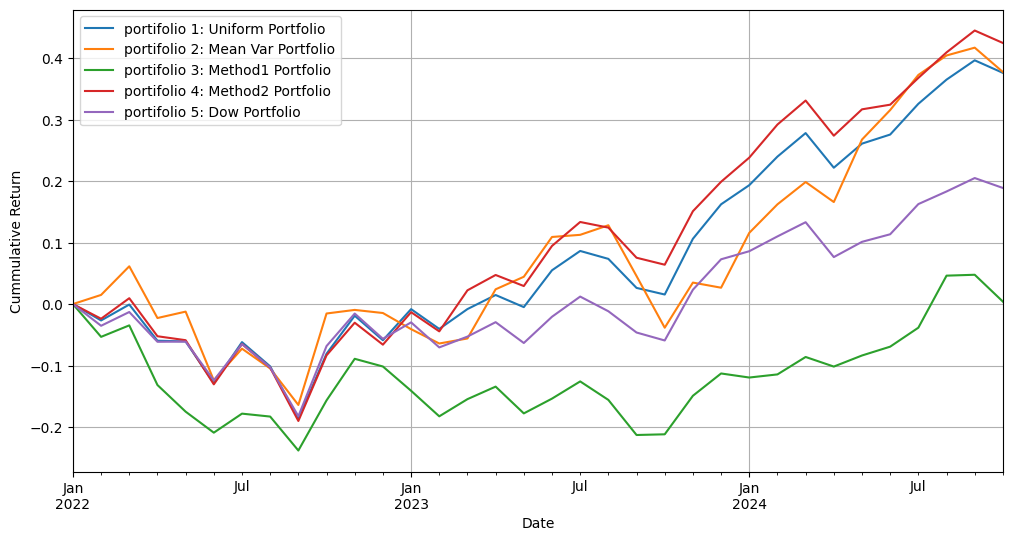

In [ ]:
#plot cumulative returns
fig, ax = plt.subplots(figsize=(12,6))
uniform_cumpod.plot(ax=ax);
min_var_cumpod.plot(ax=ax);
method1_cumpod.plot(ax=ax);
method2_cumpod.plot(ax=ax);
dow_cumpod.plot(ax=ax);
plt.legend(loc="best");
plt.grid(True)
ax.set_ylabel("Cumulative Return");
ax.set_xlabel("Date");
#ax.set_title('Backtest based on the data from 2012-01-01 to 2024-12-01', fontsize=14)
fig.savefig('cumulative_returns.png')

In [ ]:
from empyrical import max_drawdown, alpha_beta,sortino_ratio,sharpe_ratio, annual_return, cum_returns, annual_volatility, calmar_ratio, \
stability_of_timeseries,tail_ratio

def portfolio_metrics(returns, factor_returns= None,period = 'monthly', portfolio_name=None):
  portfolio_perf = pd.DataFrame({'Annual Return': [annual_return(returns.values, period=period)]})
  portfolio_perf['portfolio_name'] = portfolio_name
  portfolio_perf['Cumulative Returns'] = cum_returns(returns.values)[-1]
  portfolio_perf['Annual Volatility'] = annual_volatility(returns.values, period=period)
  portfolio_perf['Sharpe Ratio'] = sharpe_ratio(returns.values, period=period)
  portfolio_perf['Calmar Ratio'] = calmar_ratio(returns.values, period=period) #Determines the Calmar ratio, or drawdown ratio, of a strategy.
  portfolio_perf['Stability'] =   stability_of_timeseries(returns.values)
  portfolio_perf['Max Drawdown'] = max_drawdown(returns.values)
  portfolio_perf['Sortino Ratio'] = sortino_ratio(returns.values,period=period)
  portfolio_perf['Tail Ratio'] =  tail_ratio(returns.values)
  portfolio_perf['Alpha'] =   alpha_beta(returns.values,factor_returns = factor_returns.values,period=period)[0]
  portfolio_perf['Beta'] =   alpha_beta(returns.values, factor_returns = factor_returns.values, period=period)[1]
  portfolio_perf.set_index('portfolio_name', inplace=True)
  return portfolio_perf.T.round(2)

In [ ]:
portfolio_perf = portfolio_metrics(dow_return,dow_return,portfolio_name = 'Dow')
uniform_perf = portfolio_metrics(uniform_returns,dow_return,portfolio_name = 'Uniform')
min_var_perf = portfolio_metrics(min_var_returns,dow_return,portfolio_name = 'Mean Var')
method1_perf = portfolio_metrics(method1_returns,dow_return,portfolio_name = 'Method1')
method2_perf = portfolio_metrics(method2_returns,dow_return,portfolio_name = 'Method2')
portfolio_perf = pd.concat([portfolio_perf,uniform_perf], axis=1)
portfolio_perf = pd.concat([portfolio_perf,min_var_perf], axis=1)
portfolio_perf = pd.concat([portfolio_perf,method1_perf], axis=1)
portfolio_perf = pd.concat([portfolio_perf,method2_perf], axis=1)
portfolio_perf

portfolio_name,Dow,Uniform,Mean Var,Method1,Method2
Annual Return,0.06,0.12,0.12,0.00,0.13
Cumulative Returns,0.19,0.38,0.38,0.00,0.42
Annual Volatility,0.17,0.17,0.20,0.17,0.17
Sharpe Ratio,0.46,0.76,0.67,0.09,0.83
Calmar Ratio,0.35,0.64,0.56,0.01,0.67
Stability,0.72,0.83,0.69,0.25,0.86
Max Drawdown,-0.18,-0.19,-0.21,-0.24,-0.20
Sortino Ratio,0.77,1.30,1.14,0.14,1.43
Tail Ratio,1.33,1.27,1.09,1.23,1.16
Alpha,0.00,0.05,0.07,-0.05,0.07


In [ ]:
portfolio_perf.to_csv('portfolio_perf.csv')